5 C

Dataset Shape:
(768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies            

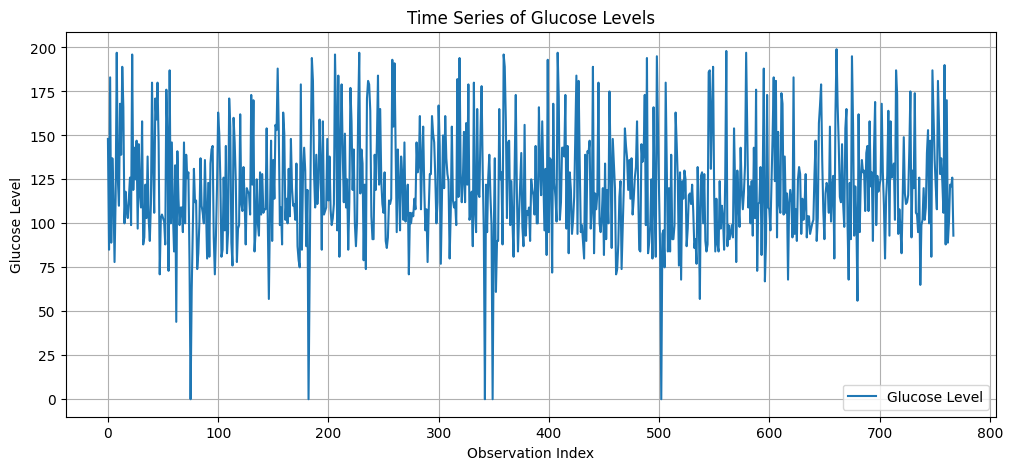

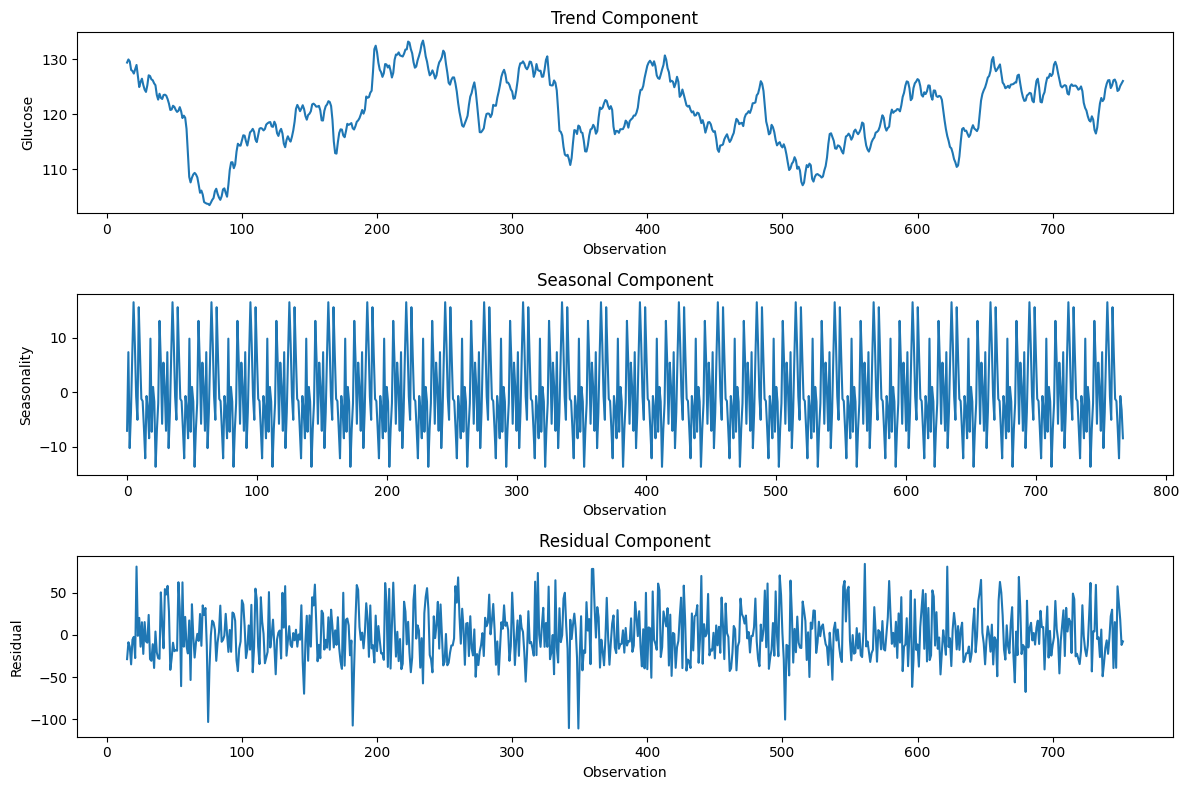

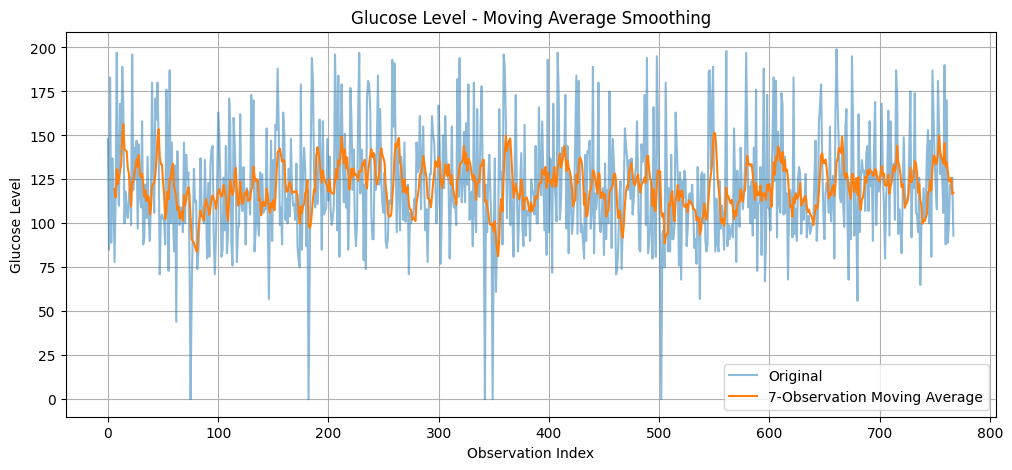


Training Samples: 614
Testing Samples : 154

ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                Glucose   No. Observations:                  614
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3053.695
Date:                Fri, 14 Aug 2026   AIC                           6119.390
Time:                        04:26:35   BIC                           6145.901
Sample:                             0   HQIC                          6129.700
                                - 614                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7381      0.042    -17.688      0.000      -0.820      -0.656
ar.L2         -0.5719      0.052    -11.084      0.000      -0.67

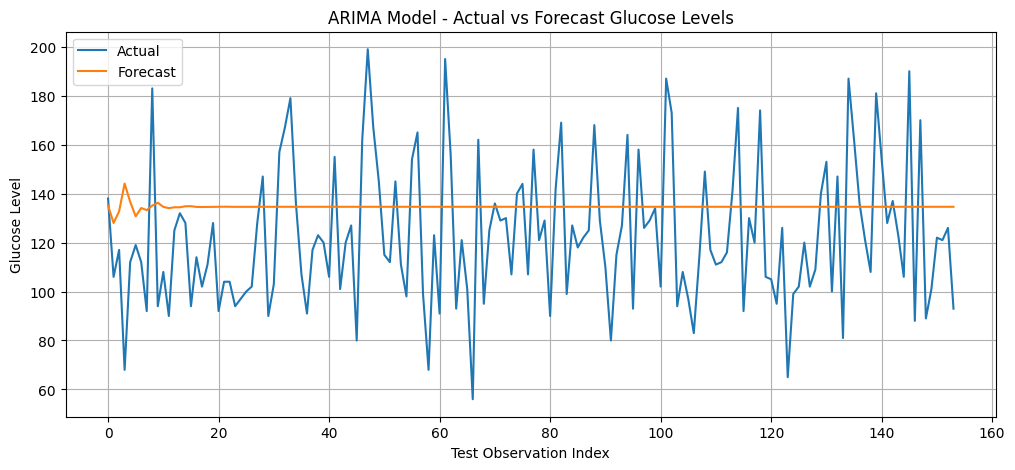


Forecast Results:
    Actual    Forecast
0    138.0  135.115757
1    106.0  128.020161
2    117.0  132.754886
3     68.0  144.113478
4    112.0  136.702528
5    119.0  130.728257
6    112.0  134.114916
7     92.0  133.268321
8    183.0  135.101926
9     94.0  136.271988
10   108.0  134.592861
11    90.0  134.068127
12   125.0  134.412480
13   132.0  134.423598
14   128.0  134.831845
15    94.0  134.869941
16   114.0  134.575513
17   102.0  134.530114
18   111.0  134.567421
19   128.0  134.603860


In [3]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA


# ============================================
# LOAD DATASET FROM ONLINE
# ============================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

diabetes_data = pd.read_csv(url, names=columns)


# ============================================
# CHECK AND PREVIEW DATA
# ============================================

print("Dataset Shape:")
print(diabetes_data.shape)

print("\nFirst 5 Rows:")
print(diabetes_data.head())

print("\nDataset Information:")
print(diabetes_data.info())


# ============================================
# SELECT GLUCOSE DATA
# ============================================

glucose = diabetes_data["Glucose"].astype(float)

print("\nGlucose Statistics:")
print(glucose.describe())


# ============================================
# PLOT TIME SERIES DATA
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    glucose,
    label="Glucose Level"
)

plt.xlabel("Observation Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")

plt.legend()
plt.grid(True)

plt.show()


# ============================================
# DECOMPOSE TIME SERIES
# ============================================

# period=30 means we examine a repeating
# pattern every 30 observations.

decomposition = seasonal_decompose(
    glucose,
    model="additive",
    period=30
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 8)
)

decomposition.trend.plot(
    ax=axes[0]
)

axes[0].set_title("Trend Component")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Glucose")


decomposition.seasonal.plot(
    ax=axes[1]
)

axes[1].set_title("Seasonal Component")
axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Seasonality")


decomposition.resid.plot(
    ax=axes[2]
)

axes[2].set_title("Residual Component")
axes[2].set_xlabel("Observation")
axes[2].set_ylabel("Residual")


plt.tight_layout()
plt.show()


# ============================================
# MOVING AVERAGE SMOOTHING
# ============================================

diabetes_data["Glucose_MA"] = (
    diabetes_data["Glucose"]
    .rolling(window=7)
    .mean()
)


plt.figure(figsize=(12, 5))

plt.plot(
    diabetes_data["Glucose"],
    label="Original",
    alpha=0.5
)

plt.plot(
    diabetes_data["Glucose_MA"],
    label="7-Observation Moving Average"
)

plt.xlabel("Observation Index")
plt.ylabel("Glucose Level")

plt.title(
    "Glucose Level - Moving Average Smoothing"
)

plt.legend()
plt.grid(True)

plt.show()


# ============================================
# TRAIN-TEST SPLIT
# ============================================

train_size = int(len(glucose) * 0.8)

train = glucose.iloc[:train_size]

test = glucose.iloc[train_size:]


print("\nTraining Samples:", len(train))
print("Testing Samples :", len(test))


# ============================================
# BUILD ARIMA MODEL
# ============================================

# ARIMA(p,d,q)
#
# p = autoregressive terms
# d = differencing
# q = moving average terms

model = ARIMA(
    train,
    order=(5, 1, 0)
)

fitted_model = model.fit()


# ============================================
# DISPLAY MODEL SUMMARY
# ============================================

print("\nARIMA MODEL SUMMARY")
print("===================")

print(fitted_model.summary())


# ============================================
# FORECAST TEST DATA
# ============================================

forecast = fitted_model.forecast(
    steps=len(test)
)


# ============================================
# FORECAST VS ACTUAL
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(test)),
    test.values,
    label="Actual"
)

plt.plot(
    range(len(test)),
    forecast.values,
    label="Forecast"
)

plt.xlabel("Test Observation Index")
plt.ylabel("Glucose Level")

plt.title(
    "ARIMA Model - Actual vs Forecast Glucose Levels"
)

plt.legend()
plt.grid(True)

plt.show()


# ============================================
# FORECAST TABLE
# ============================================

results = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast.values
})

print("\nForecast Results:")
print(results.head(20))